In [44]:
import kagglehub
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import DBSCAN

In [2]:
# PARTE 2 - 1 Baixe os dados disponibilizados na plataforma Kaggle sobre dados sócio-econômicos 
# e de saúde que determinam o índice de desenvolvimento de um país. 
# Esses dados estão disponibilizados através do link: 
# https://www.kaggle.com/datasets/rohan0301/unsupervised-learning-on-country-data
path = kagglehub.dataset_download("rohan0301/unsupervised-learning-on-country-data")
print(path)
# Carregar os dados
df = pd.read_csv(path+"\\Country-data.csv", sep = ",")

# PARTE 2 - 2 Quantos países existem no dataset?
print('Qtde Países no dataset: ', df['country'].count())

C:\Users\alan echer\.cache\kagglehub\datasets\rohan0301\unsupervised-learning-on-country-data\versions\2
Qtde Países no dataset:  167


In [3]:
# Visualizando as primeiras linhas e informações básicas
print("Primeiras linhas do dataset:")
print(df.head())
print("\nInformações do dataset:")
print(df.info())
print("\nEstatísticas descritivas:")
print(df.describe())
print("\nValores nulos por coluna:")
print(df.isnull().sum())

Primeiras linhas do dataset:
               country  child_mort  exports  health  imports  income  \
0          Afghanistan        90.2     10.0    7.58     44.9    1610   
1              Albania        16.6     28.0    6.55     48.6    9930   
2              Algeria        27.3     38.4    4.17     31.4   12900   
3               Angola       119.0     62.3    2.85     42.9    5900   
4  Antigua and Barbuda        10.3     45.5    6.03     58.9   19100   

   inflation  life_expec  total_fer   gdpp  
0       9.44        56.2       5.82    553  
1       4.49        76.3       1.65   4090  
2      16.10        76.5       2.89   4460  
3      22.40        60.1       6.16   3530  
4       1.44        76.8       2.13  12200  

Informações do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort

In [4]:
# Remover colunas não numéricas, caso existam (ex: nomes dos países)
X = df.select_dtypes(include=[np.number])

In [5]:
# PARTE 2 - 3 Os dados possuem variação alta, presença de outliers e diferença 
# de escala entre variáveis
# TRATAMENTO DE OUTLIERS - Foi preciso aplicar logaritmos nas colunas que 
# possuiam outliers:
# 'child_mort', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp', 
# 'exports', 'imports'
# verificando se o valor era negativo antes de aplicar o logaritmo

In [6]:
# Tratar outliers
cols_to_log = ['child_mort', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp', 'exports', 'imports']
for col in cols_to_log:
    min_val = X[col].min()
    if min_val <= 0:
        X[col] = np.log1p(X[col] + abs(min_val) + 1)
    else:
        X[col] = np.log1p(X[col])

In [7]:
# PARTE 2 - 3 Os dados possuem variação alta, presença de outliers e diferença de escala entre variáveis
# NORMALIZAÇÃO - Foi preciso normalizar os dados para reduzir a amplitude dos valores
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [8]:
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

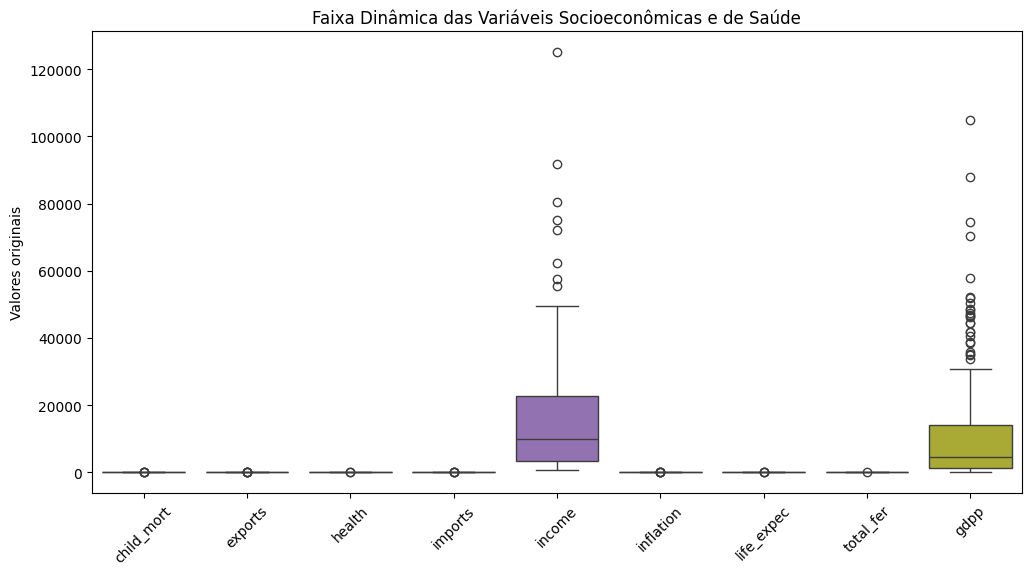

In [9]:
# --- Boxplot para ver a faixa dinâmica ---
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.title("Faixa Dinâmica das Variáveis Socioeconômicas e de Saúde")
plt.xticks(rotation=45)
plt.ylabel("Valores originais")
plt.show()

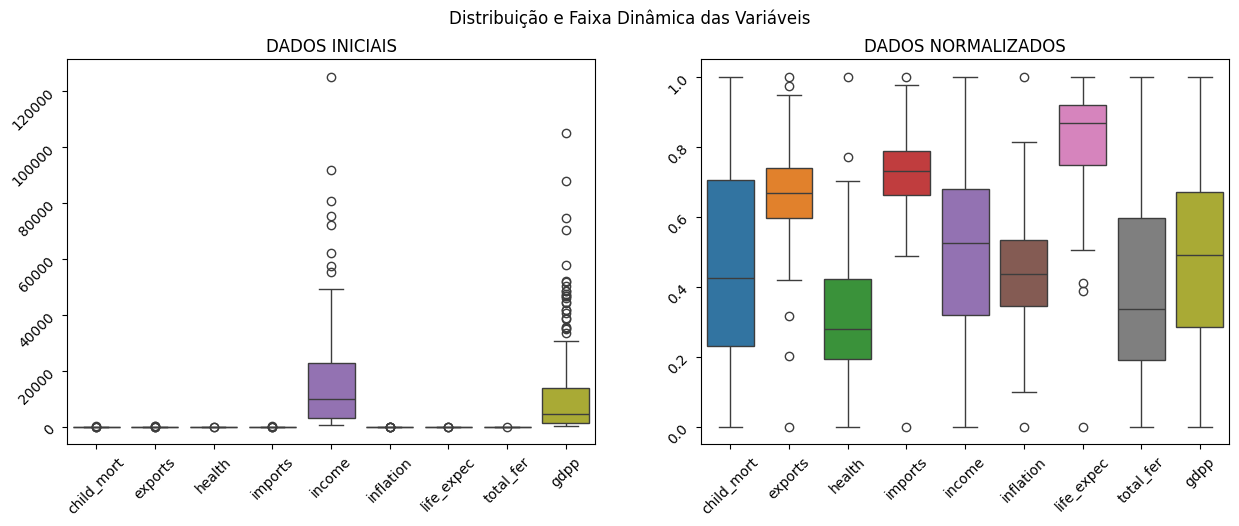

In [10]:
f, ax = plt.subplots(1, 2, figsize=(15,5))

sns.boxplot(data=df.drop('country', axis=1), ax=ax[0])
ax[0].set_title('DADOS INICIAIS')
ax[0].tick_params(labelrotation=45)

sns.boxplot(data=X_scaled_df, ax=ax[1])
ax[1].set_title('DADOS NORMALIZADOS')
ax[1].tick_params(labelrotation=45)

plt.suptitle('Distribuição e Faixa Dinâmica das Variáveis')
plt.show()

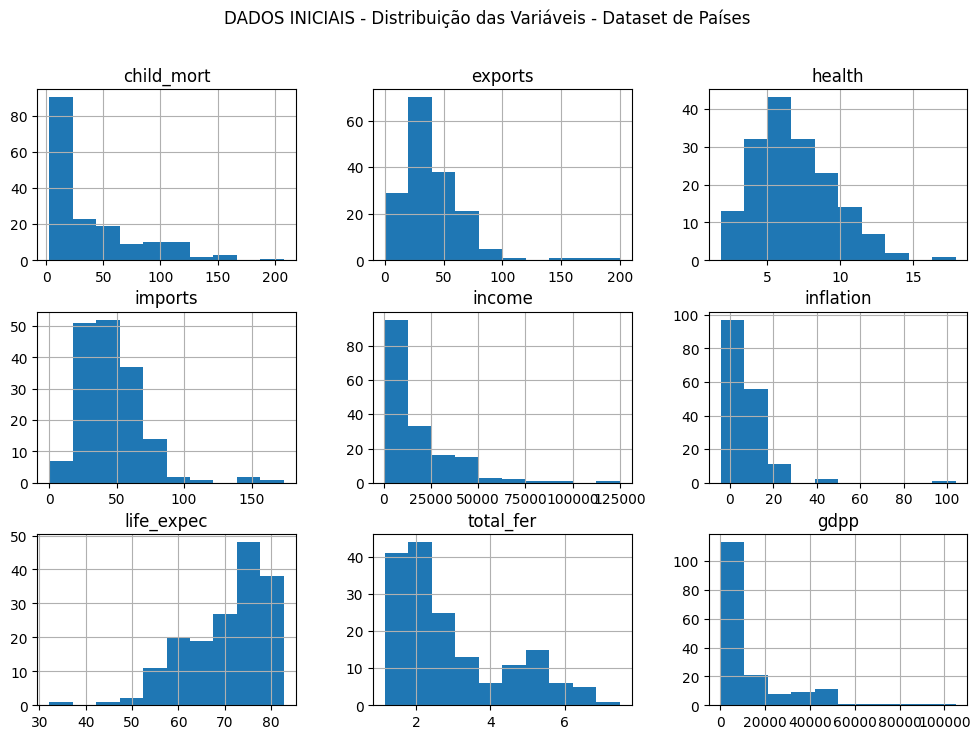

In [11]:
df.drop('country', axis=1).hist(figsize=(12,8))
plt.suptitle("DADOS INICIAIS - Distribuição das Variáveis - Dataset de Países")
plt.show()

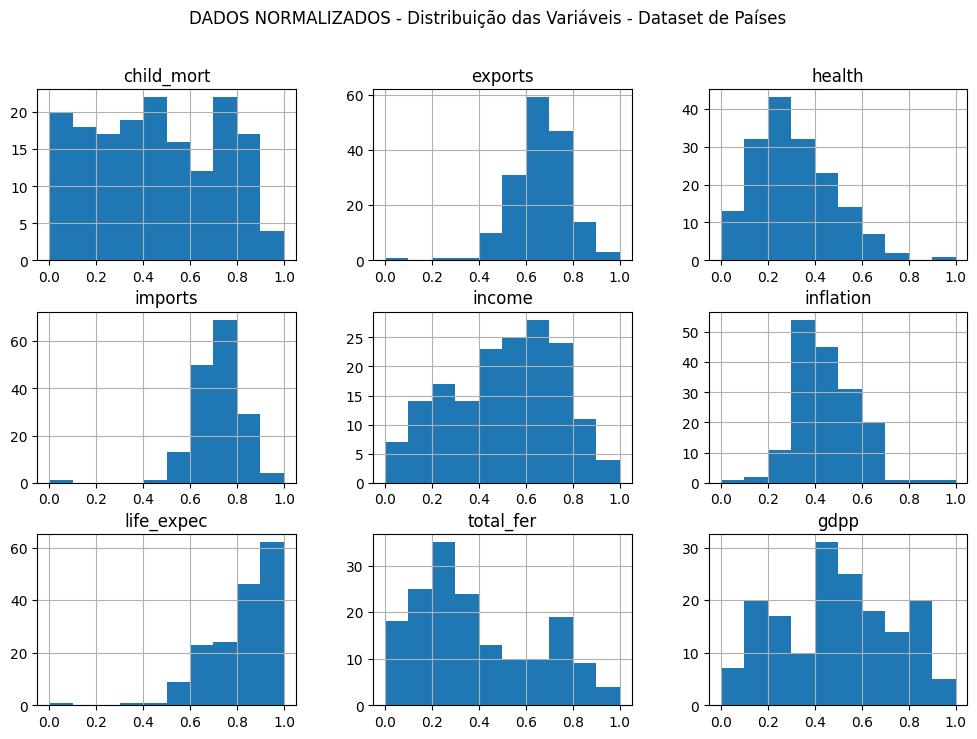

In [12]:
X_scaled_df.hist(figsize=(12,8))
plt.suptitle("DADOS NORMALIZADOS - Distribuição das Variáveis - Dataset de Países")
plt.show()

In [13]:
number_of_clusters = 3
random_seed = 42

hierarquical = AgglomerativeClustering(
    n_clusters=number_of_clusters, 
    linkage='ward', 
    metric='euclidean'
)

X_scaled_df['cluster_hierarquical'] = hierarquical.fit_predict(X_scaled)
X_scaled_df['cluster_hierarquical']


0      0
1      1
2      1
3      0
4      1
      ..
162    0
163    1
164    0
165    0
166    0
Name: cluster_hierarquical, Length: 167, dtype: int64

In [14]:
kmeans = KMeans(
    n_clusters=number_of_clusters,
    random_state=random_seed
)

X_scaled_df['cluster_kmeans'] = kmeans.fit_predict(X_scaled)
X_scaled_df['cluster_kmeans']

0      2
1      0
2      0
3      2
4      1
      ..
162    0
163    0
164    0
165    2
166    2
Name: cluster_kmeans, Length: 167, dtype: int32

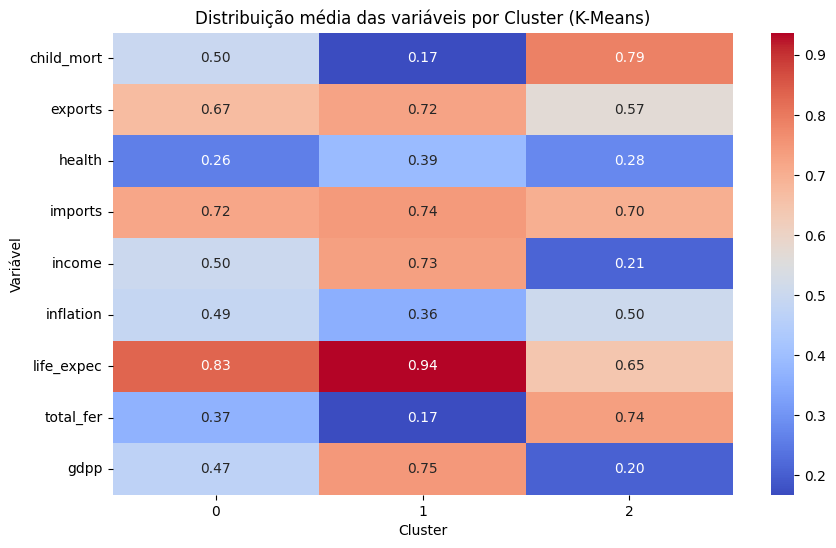

In [15]:
# Médias por cluster (distribuição central das dimensões)
means = X_scaled_df.drop('cluster_hierarquical', axis=1).groupby('cluster_kmeans').mean().T
plt.figure(figsize=(10,6))
sns.heatmap(means, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Distribuição média das variáveis por Cluster (K-Means)")
plt.ylabel("Variável")
plt.xlabel("Cluster")
plt.show()

In [16]:
# Obter os centróides
centroids = kmeans.cluster_centers_

# Calcular a distância de cada ponto ao centróide do seu cluster
distances = []
for i, row in enumerate(X_scaled):
    cluster_label = X_scaled_df.loc[i, 'cluster_kmeans']
    centroid = centroids[cluster_label]
    distance = np.linalg.norm(row - centroid)
    distances.append(distance)

X_scaled_df['distance_to_centroid'] = distances

X_scaled_df['country'] = df['country']
# Encontrar o país mais representativo de cada cluster
representative_countries = X_scaled_df.loc[
    X_scaled_df.groupby('cluster_kmeans')['distance_to_centroid'].idxmin(),
    ['country', 'cluster_kmeans', 'distance_to_centroid']]
X_scaled_df = X_scaled_df.drop('country', axis=1)

print("Países que melhor representam cada cluster:\n")
print(representative_countries)

Países que melhor representam cada cluster:

      country  cluster_kmeans  distance_to_centroid
118  Paraguay               0              0.128643
41    Croatia               1              0.145154
147  Tanzania               2              0.098071


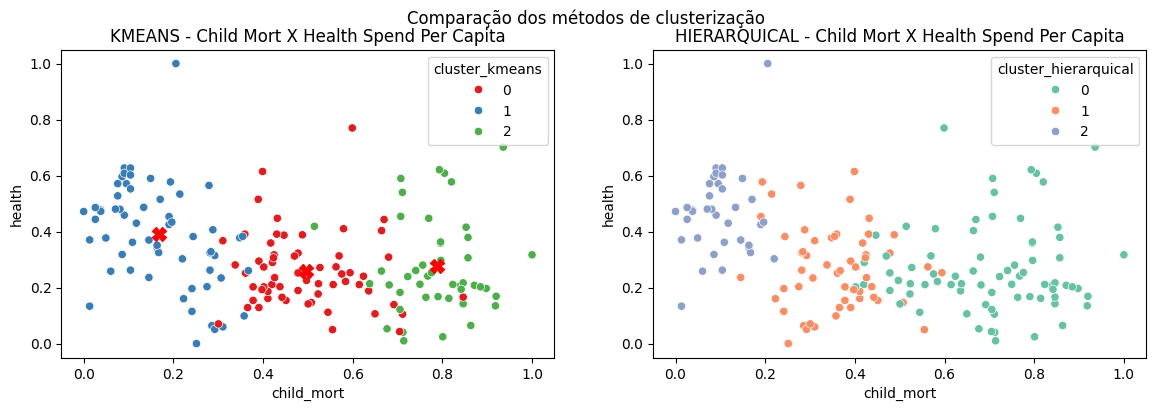

In [17]:
f, ax = plt.subplots(1, 2, figsize=(14,4))
x_column = 'child_mort'
y_column = 'health'
pos_for_x_column = 0
pos_for_y_column = 2
sns.scatterplot(data=X_scaled_df, x=x_column, y=y_column, hue=X_scaled_df['cluster_kmeans'], 
                palette='Set1', ax=ax[0])
ax[0].set_title('KMEANS - Child Mort X Health Spend Per Capita')
ax[0].plot(
    [x[pos_for_x_column] for x in kmeans.cluster_centers_],
    [x[pos_for_y_column] for x in kmeans.cluster_centers_],
    'X',
    color='red',
    markersize=10,
)
sns.scatterplot(data=X_scaled_df, x=x_column, y=y_column, hue=X_scaled_df['cluster_hierarquical'],
                 palette='Set2', ax=ax[1])
ax[1].set_title('HIERARQUICAL - Child Mort X Health Spend Per Capita')
plt.suptitle('Comparação dos métodos de clusterização')
plt.show()

In [18]:
print("\nDistribuição dos clusters (K-Means):")
print(X_scaled_df['cluster_kmeans'].value_counts())

print("\nDistribuição dos clusters (Hierárquico):")
print(X_scaled_df['cluster_hierarquical'].value_counts())


Distribuição dos clusters (K-Means):
cluster_kmeans
0    61
1    61
2    45
Name: count, dtype: int64

Distribuição dos clusters (Hierárquico):
cluster_hierarquical
0    75
1    55
2    37
Name: count, dtype: int64


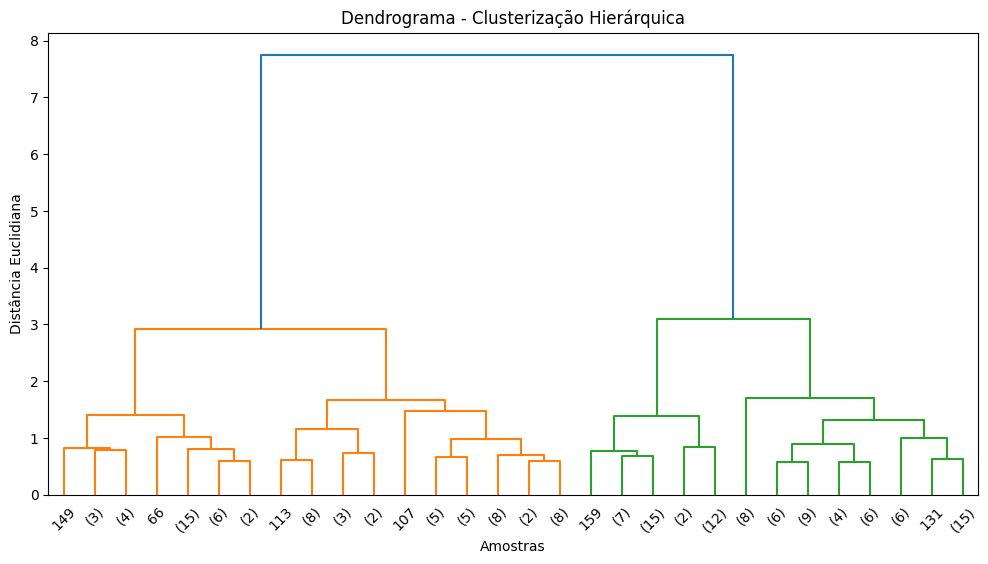

In [19]:
Z = linkage(X_scaled, method='ward')
plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=45., leaf_font_size=10.)
plt.title("Dendrograma - Clusterização Hierárquica")
plt.xlabel("Amostras")
plt.ylabel("Distância Euclidiana")
plt.show()

In [20]:
pd.crosstab(X_scaled_df['cluster_kmeans'], X_scaled_df['cluster_hierarquical'])

cluster_hierarquical,0,1,2
cluster_kmeans,,,
0,30,31,0
1,0,24,37
2,45,0,0


In [21]:
import numpy as np
import pandas as pd
from sklearn.metrics import pairwise_distances

def k_medoids(X, k, max_iter=100, random_state=42):
    np.random.seed(random_state)
    
    # 1️⃣ Inicialização: escolher aleatoriamente k pontos como medóides iniciais
    medoid_indices = np.random.choice(len(X), k, replace=False)
    medoids = X[medoid_indices]
    
    for it in range(max_iter):
        # 2️⃣ Atribuição: calcular distância de cada ponto a cada medóide
        distances = pairwise_distances(X, medoids)
        labels = np.argmin(distances, axis=1)
        
        new_medoids = np.copy(medoids)
        
        # 3️⃣ Atualização: para cada cluster, escolher novo medóide
        for i in range(k):
            cluster_points = X[labels == i]
            if len(cluster_points) == 0:
                continue
            
            # Calcular matriz de distâncias dentro do cluster
            intra_dist = pairwise_distances(cluster_points)
            total_dist = intra_dist.sum(axis=1)
            
            # Escolher o ponto que minimiza a soma das distâncias
            new_medoid = cluster_points[np.argmin(total_dist)]
            new_medoids[i] = new_medoid
        
        # 4️⃣ Verificar convergência
        if np.all(medoids == new_medoids):
            print(f"Convergência alcançada na iteração {it+1}.")
            break
        
        medoids = new_medoids
    
    return labels, medoids

In [22]:
X = X_scaled_df.drop('cluster_hierarquical', axis=1).drop('cluster_kmeans',axis=1).values

medoids_labels, medoids = k_medoids(X, k=3)

df['cluster_medoide'] = medoids_labels
print(df.head())

Convergência alcançada na iteração 2.
               country  child_mort  exports  health  imports  income  \
0          Afghanistan        90.2     10.0    7.58     44.9    1610   
1              Albania        16.6     28.0    6.55     48.6    9930   
2              Algeria        27.3     38.4    4.17     31.4   12900   
3               Angola       119.0     62.3    2.85     42.9    5900   
4  Antigua and Barbuda        10.3     45.5    6.03     58.9   19100   

   inflation  life_expec  total_fer   gdpp  cluster_medoide  
0       9.44        56.2       5.82    553                1  
1       4.49        76.3       1.65   4090                2  
2      16.10        76.5       2.89   4460                2  
3      22.40        60.1       6.16   3530                1  
4       1.44        76.8       2.13  12200                2  


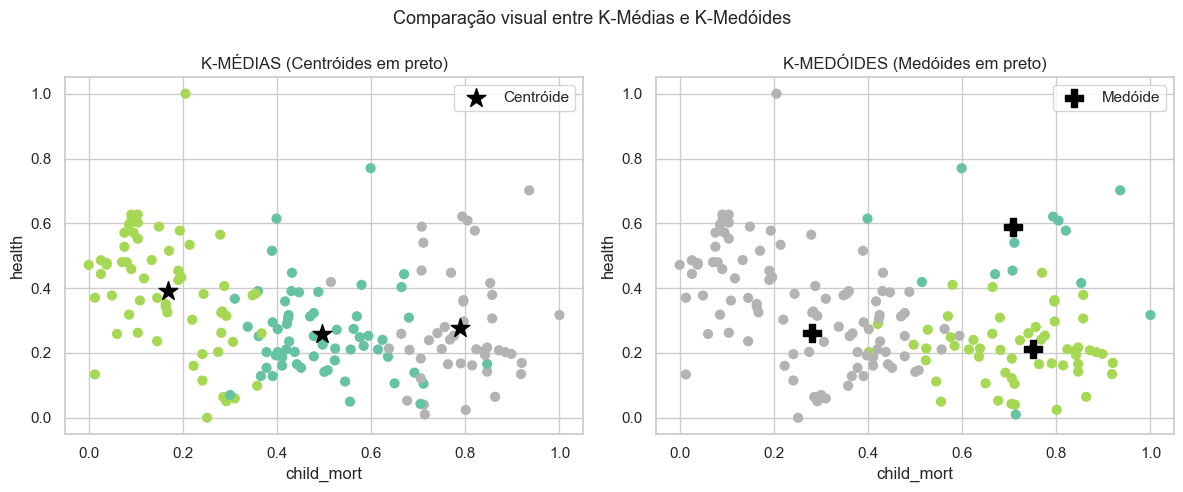

In [23]:
# --------------------------------------------------------
# 5️⃣ Visualização: comparação lado a lado
# --------------------------------------------------------
sns.set(style="whitegrid", palette="Set2")
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Para facilitar a visualização, usaremos apenas duas variáveis:
x_idx, y_idx = 0, 2  # exemplo: child_mort vs health

# K-MEANS
axes[0].scatter(X_scaled[:, x_idx], X_scaled[:, y_idx], c=X_scaled_df['cluster_kmeans'], cmap='Set2', s=40)
axes[0].scatter(centroids[:, x_idx], centroids[:, y_idx], marker='*', c='black', s=200, label='Centróide')
axes[0].set_title("K-MÉDIAS (Centróides em preto)")
axes[0].set_xlabel(df.drop(columns=['country']).columns[x_idx])
axes[0].set_ylabel(df.drop(columns=['country']).columns[y_idx])
axes[0].legend()

# K-MEDÓIDES
axes[1].scatter(X_scaled[:, x_idx], X_scaled[:, y_idx], c=medoids_labels, cmap='Set2', s=40)
axes[1].scatter(medoids[:, x_idx], medoids[:, y_idx], marker='P', c='black', s=150, label='Medóide')
axes[1].set_title("K-MEDÓIDES (Medóides em preto)")
axes[1].set_xlabel(df.drop(columns=['country']).columns[x_idx])
axes[1].set_ylabel(df.drop(columns=['country']).columns[y_idx])
axes[1].legend()

plt.suptitle("Comparação visual entre K-Médias e K-Medóides", fontsize=13)
plt.tight_layout()
plt.show()

In [24]:
# SEGUNDA MATÉRIA VALIDAÇÃO DE MODELOS DE CLUSTERIZAÇÃO

In [35]:
# ---- ESCOLHA DO K ÓTIMO PELO ÍNDICE DE SILHUETA ----
K_range = range(2, 11)
sil_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    sil_scores.append(sil)
    print(f"k={k} -> Índice de Silhueta: {sil:.4f}")

k=2 -> Índice de Silhueta: 0.4201
k=3 -> Índice de Silhueta: 0.3251
k=4 -> Índice de Silhueta: 0.2502
k=5 -> Índice de Silhueta: 0.2584
k=6 -> Índice de Silhueta: 0.2248
k=7 -> Índice de Silhueta: 0.2217
k=8 -> Índice de Silhueta: 0.2215
k=9 -> Índice de Silhueta: 0.2086
k=10 -> Índice de Silhueta: 0.2083


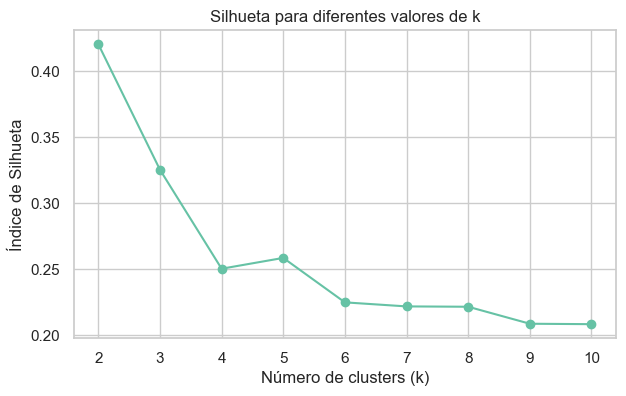

In [26]:
# Plot da silhueta
plt.figure(figsize=(7,4))
plt.plot(list(K_range), sil_scores, marker='o')
plt.xlabel("Número de clusters (k)")
plt.ylabel("Índice de Silhueta")
plt.title("Silhueta para diferentes valores de k")
plt.grid(True)
plt.show()

In [27]:
# Escolhe o melhor k
best_k = K_range[np.argmax(sil_scores)]
print(f"\nMelhor k encontrado: {best_k}")

# ---- K-MÉDIAS FINAL ----
kmeans_final = KMeans(n_clusters=best_k, random_state=42)
df["kmeans_cluster"] = kmeans_final.fit_predict(X_scaled)

print("\nClusters atribuídos (K-MéDias):")
print(df["kmeans_cluster"].value_counts())


Melhor k encontrado: 2

Clusters atribuídos (K-MéDias):
kmeans_cluster
1    92
0    75
Name: count, dtype: int64


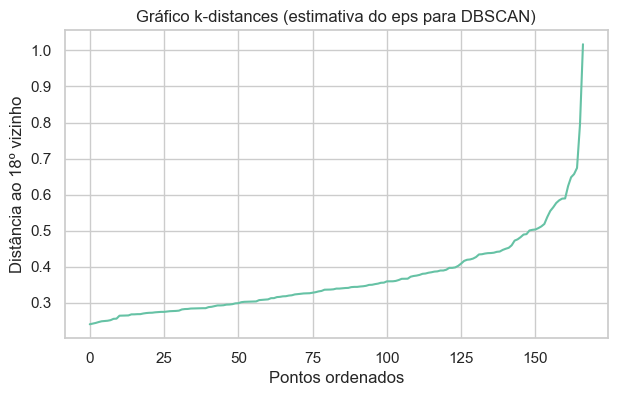

In [ ]:
# número de vizinhos usado para estimar eps
n_neighbors = 18

neighbors = NearestNeighbors(n_neighbors=n_neighbors)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# distância ao vizinho
distances = np.sort(distances[:, n_neighbors - 1])

plt.figure(figsize=(7,4))
plt.plot(distances)
plt.title("Gráfico k-distances (estimativa do eps para DBSCAN)")
plt.xlabel("Pontos ordenados")
plt.ylabel(f"Distância ao {n_neighbors}º vizinho")
plt.grid(True)
plt.show()

In [39]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

eps_values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
min_samples = 18

print("\nTestando DBSCAN com diferentes eps:\n")

resultados = []

for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=min_samples)
    labels = db.fit_predict(X_scaled)

    # número de clusters encontrados (ignora ruído -1)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    if n_clusters > 1:
        sil = silhouette_score(X_scaled, labels)
        resultados.append((eps, n_clusters, sil))
        print(f"eps={eps} → clusters={n_clusters}, silhueta={sil:.4f}")
    else:
        print(f"eps={eps} → não formou clusters válidos")


Testando DBSCAN com diferentes eps:

eps=0.1 → não formou clusters válidos
eps=0.2 → não formou clusters válidos
eps=0.3 → clusters=2, silhueta=0.2232
eps=0.4 → não formou clusters válidos
eps=0.5 → não formou clusters válidos
eps=0.6 → não formou clusters válidos
eps=0.7 → não formou clusters válidos
eps=0.8 → não formou clusters válidos
eps=0.9 → não formou clusters válidos
eps=1.0 → não formou clusters válidos


In [42]:
best_eps = 0.3
best_min_samples = 18

dbscan_final = DBSCAN(eps=best_eps, min_samples=best_min_samples)
df["dbscan_cluster"] = dbscan_final.fit_predict(X_scaled)

print("\nClusters encontrados pelo DBSCAN:")
print(df["dbscan_cluster"].value_counts())


Clusters encontrados pelo DBSCAN:
dbscan_cluster
 0    101
-1     43
 1     23
Name: count, dtype: int64


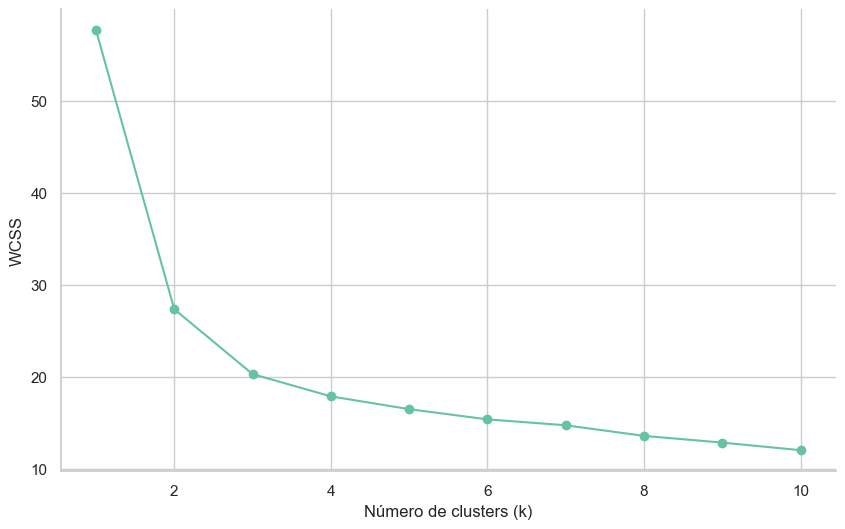

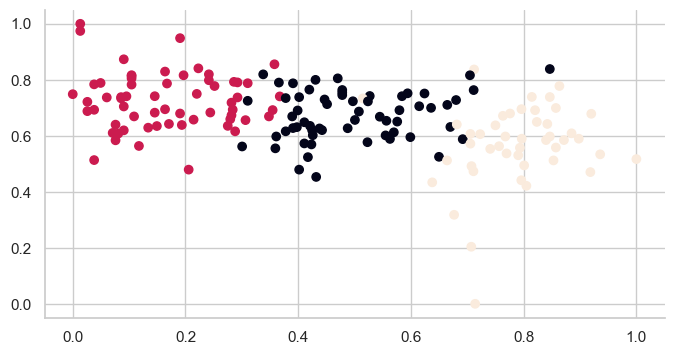

In [43]:
K_range = range(1, 11)
wss_list = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wss_list.append(kmeans.inertia_)
    
def elbow_plot(wss_list, k_init=1):
    f, ax = plt.subplots(figsize=(10,6))
    ax.plot(range(k_init, (len(wss_list)+1)), wss_list, marker='o')
    ax.set_xlabel('Número de clusters (k)')
    ax.set_ylabel('WCSS')

    sns.despine()
    plt.show()
    
# plot do WSS
elbow_plot(wss_list)

kmeans = KMeans(n_clusters=3, random_state=42).fit(X_scaled)

f, ax = plt.subplots(figsize=(8,4))
ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans.labels_)
sns.despine()
plt.show()

In [49]:

# Faixa de k testada
k_values = range(2, 11)

silhouette_scores = []
calinski_scores = []
davies_scores = []

# ==== EXECUTAR KMEANS E CALCULAR MÉTRICAS ====
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)

    silhouette_scores.append(silhouette_score(X_scaled, labels))
    calinski_scores.append(calinski_harabasz_score(X_scaled, labels))
    davies_scores.append(davies_bouldin_score(X_scaled, labels))


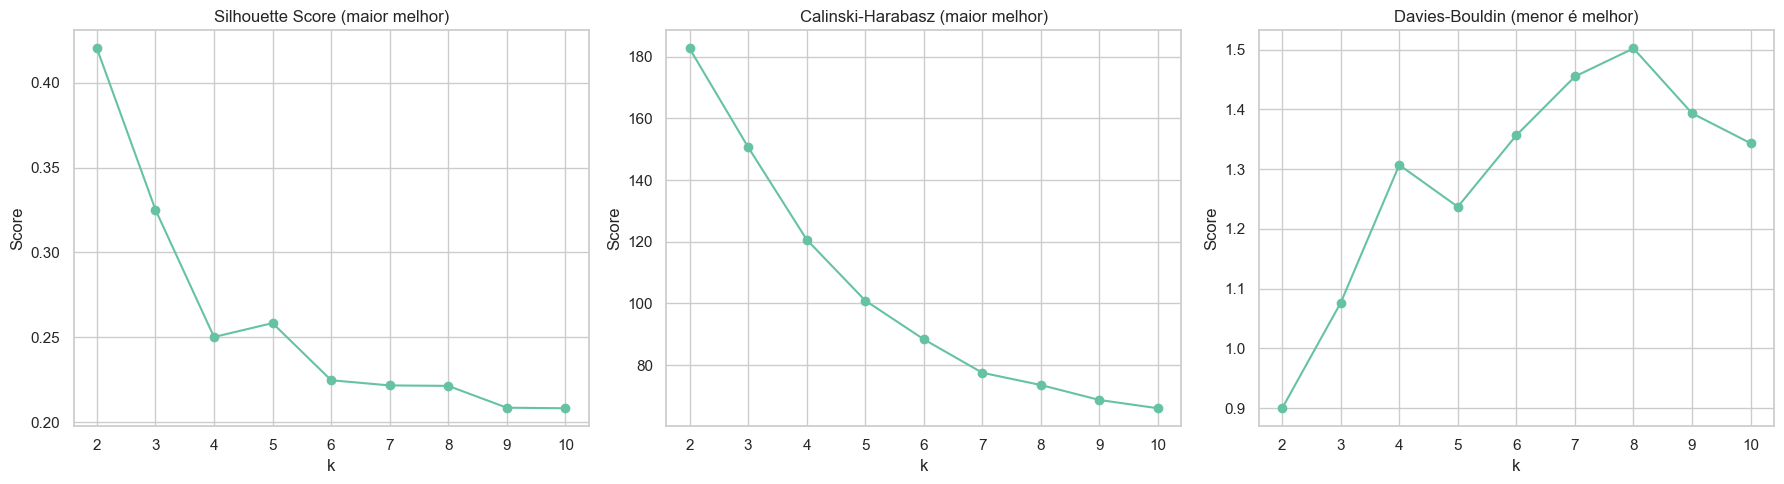

In [52]:
# ==== PLOT COM 3 GRÁFICOS ====
plt.figure(figsize=(18,5))

# --- 1. Silhouette ---
plt.subplot(1, 3, 1)
plt.plot(k_values, silhouette_scores, marker='o')
plt.title("Silhouette Score (maior melhor)")
plt.xlabel("k")
plt.ylabel("Score")
plt.grid(True)

# --- 2. Calinski-Harabasz ---
plt.subplot(1, 3, 2)
plt.plot(k_values, calinski_scores, marker='o')
plt.title("Calinski-Harabasz (maior melhor)")
plt.xlabel("k")
plt.ylabel("Score")
plt.grid(True)

# --- 3. Davies-Bouldin ---
plt.subplot(1, 3, 3)
plt.plot(k_values, davies_scores, marker='o')
plt.title("Davies-Bouldin (menor é melhor)")
plt.xlabel("k")
plt.ylabel("Score")
plt.grid(True)

plt.tight_layout()
plt.show()

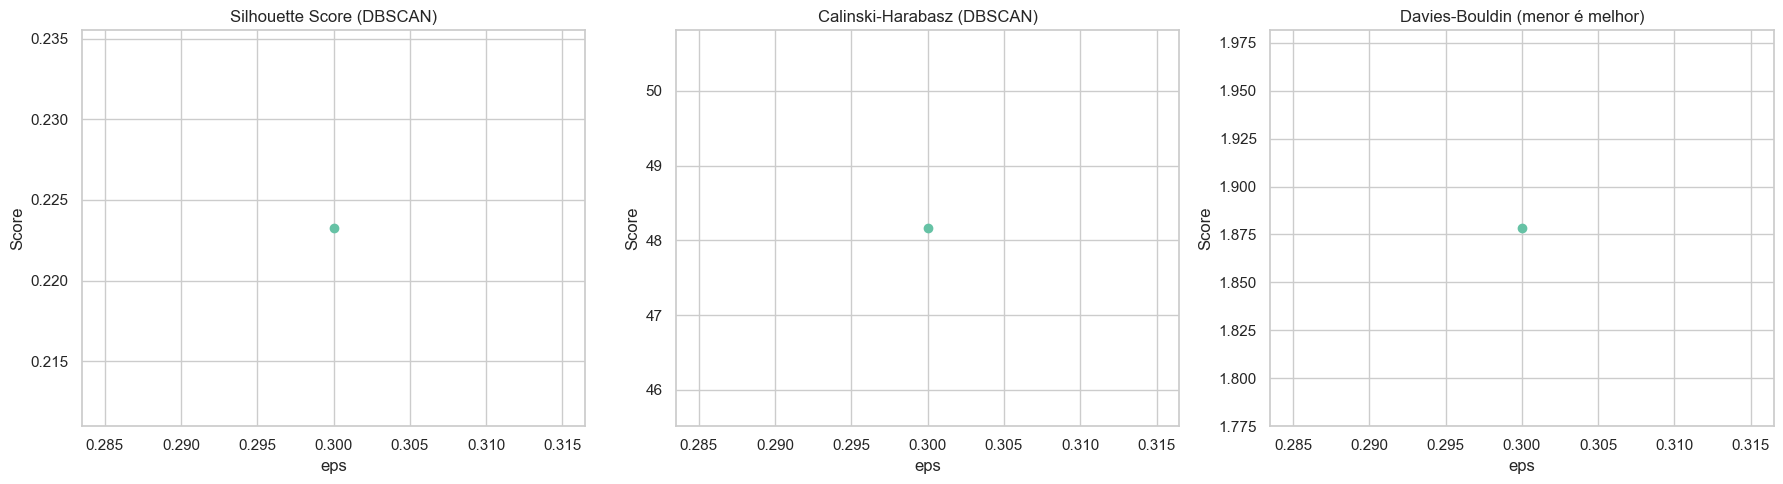

In [64]:
# Valores de eps a testar
eps_values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
min_samples = 18

silhouette_scores = []
calinski_scores = []
davies_scores = []
valid_eps = []   # eps válido para plotar

# ==== RODAR DBSCAN ====
for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(X_scaled)
    
    # Número de clusters válidos (excluindo ruído = -1)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    
    # DBSCAN só é válido se formar pelo menos 2 clusters
    if n_clusters >= 2:
        silhouette_scores.append(silhouette_score(X_scaled, labels))
        calinski_scores.append(calinski_harabasz_score(X_scaled, labels))
        davies_scores.append(davies_bouldin_score(X_scaled, labels))
        valid_eps.append(eps)

# ==== PLOTAGEM ====
plt.figure(figsize=(18,5))

# --- 1. Silhouette ---
plt.subplot(1, 3, 1)
plt.plot(valid_eps, silhouette_scores, marker='o')
plt.title("Silhouette Score (DBSCAN)")
plt.xlabel("eps")
plt.ylabel("Score")
plt.grid(True)

# --- 2. Calinski-Harabasz ---
plt.subplot(1, 3, 2)
plt.plot(valid_eps, calinski_scores, marker='o')
plt.title("Calinski-Harabasz (DBSCAN)")
plt.xlabel("eps")
plt.ylabel("Score")
plt.grid(True)

# --- 3. Davies-Bouldin ---
plt.subplot(1, 3, 3)
plt.plot(valid_eps, davies_scores, marker='o')
plt.title("Davies-Bouldin (menor é melhor)")
plt.xlabel("eps")
plt.ylabel("Score")
plt.grid(True)

plt.tight_layout()
plt.show()